In [304]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [305]:
#Loaded dataset and displayed the dataset
datas=pd.read_csv('/content/Coupen.csv')
datas.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [306]:
datas.shape

(12684, 26)

In [307]:
datas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12681 non-null  object
 1   passanger             12679 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12681 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12681 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [308]:
datas.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [309]:
#Checking for null values
datas.isna().sum()

destination                 3
passanger                   5
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  3
gender                      0
age                         0
maritalStatus               3
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 153
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [311]:
missing_percentage = datas.isnull().sum()*100/len(datas)
missing_percentage

destination              0.023652
passanger                0.039420
weather                  0.000000
temperature              0.000000
time                     0.000000
coupon                   0.000000
expiration               0.023652
gender                   0.000000
age                      0.000000
maritalStatus            0.023652
has_children             0.000000
education                0.000000
occupation               0.000000
income                   0.000000
car                     99.148534
Bar                      0.843582
CoffeeHouse              1.710817
CarryAway                1.206244
RestaurantLessThan20     1.024913
Restaurant20To50         1.490066
toCoupon_GEQ5min         0.000000
toCoupon_GEQ15min        0.000000
toCoupon_GEQ25min        0.000000
direction_same           0.000000
direction_opp            0.000000
Y                        0.000000
dtype: float64

In [312]:

# Convert all object columns to category
df_obj = datas.select_dtypes(include=['object']).copy()

for col in df_obj.columns:
    datas[col] = datas[col].astype('category')

# Check the data types to confirm the changes
print(datas.dtypes)

destination             category
passanger               category
weather                 category
temperature                int64
time                    category
coupon                  category
expiration              category
gender                  category
age                     category
maritalStatus           category
has_children               int64
education               category
occupation              category
income                  category
car                     category
Bar                     category
CoffeeHouse             category
CarryAway               category
RestaurantLessThan20    category
Restaurant20To50        category
toCoupon_GEQ5min           int64
toCoupon_GEQ15min          int64
toCoupon_GEQ25min          int64
direction_same             int64
direction_opp              int64
Y                          int64
dtype: object


In [313]:
#Car has 99 % of null value hence dropping the column
datas.drop('car', inplace=True, axis=1)

In [314]:
datas.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ5min',
       'toCoupon_GEQ15min', 'toCoupon_GEQ25min', 'direction_same',
       'direction_opp', 'Y'],
      dtype='object')

In [315]:
# Other features like bar, coffeehouse, carryaway, RestaurantLessThan20, and Restaurant20To50 have approx 1% of missing value
from sklearn.impute import SimpleImputer
# Specifying columns to impute
other_col = ['destination','passanger', 'expiration', 'maritalStatus', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

# Creating the SimpleImputer object with strategy 'most_frequent'
imputer = SimpleImputer(strategy='most_frequent')

# Fitting the imputer on the selected columns and transforming them
datas[other_col] = imputer.fit_transform(datas[other_col])

In [316]:
datas.isna().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

In [318]:
datas.select_dtypes('int64').nunique()

temperature          3
has_children         2
toCoupon_GEQ5min     1
toCoupon_GEQ15min    2
toCoupon_GEQ25min    2
direction_same       2
direction_opp        2
Y                    2
dtype: int64

In [319]:
#'toCoupon_GEQ5min' has only one unique variable Hence we are dropping that column since there will be no much effect
datas.drop('toCoupon_GEQ5min', inplace=True, axis=1)

In [320]:
datas.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ15min',
       'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Y'],
      dtype='object')

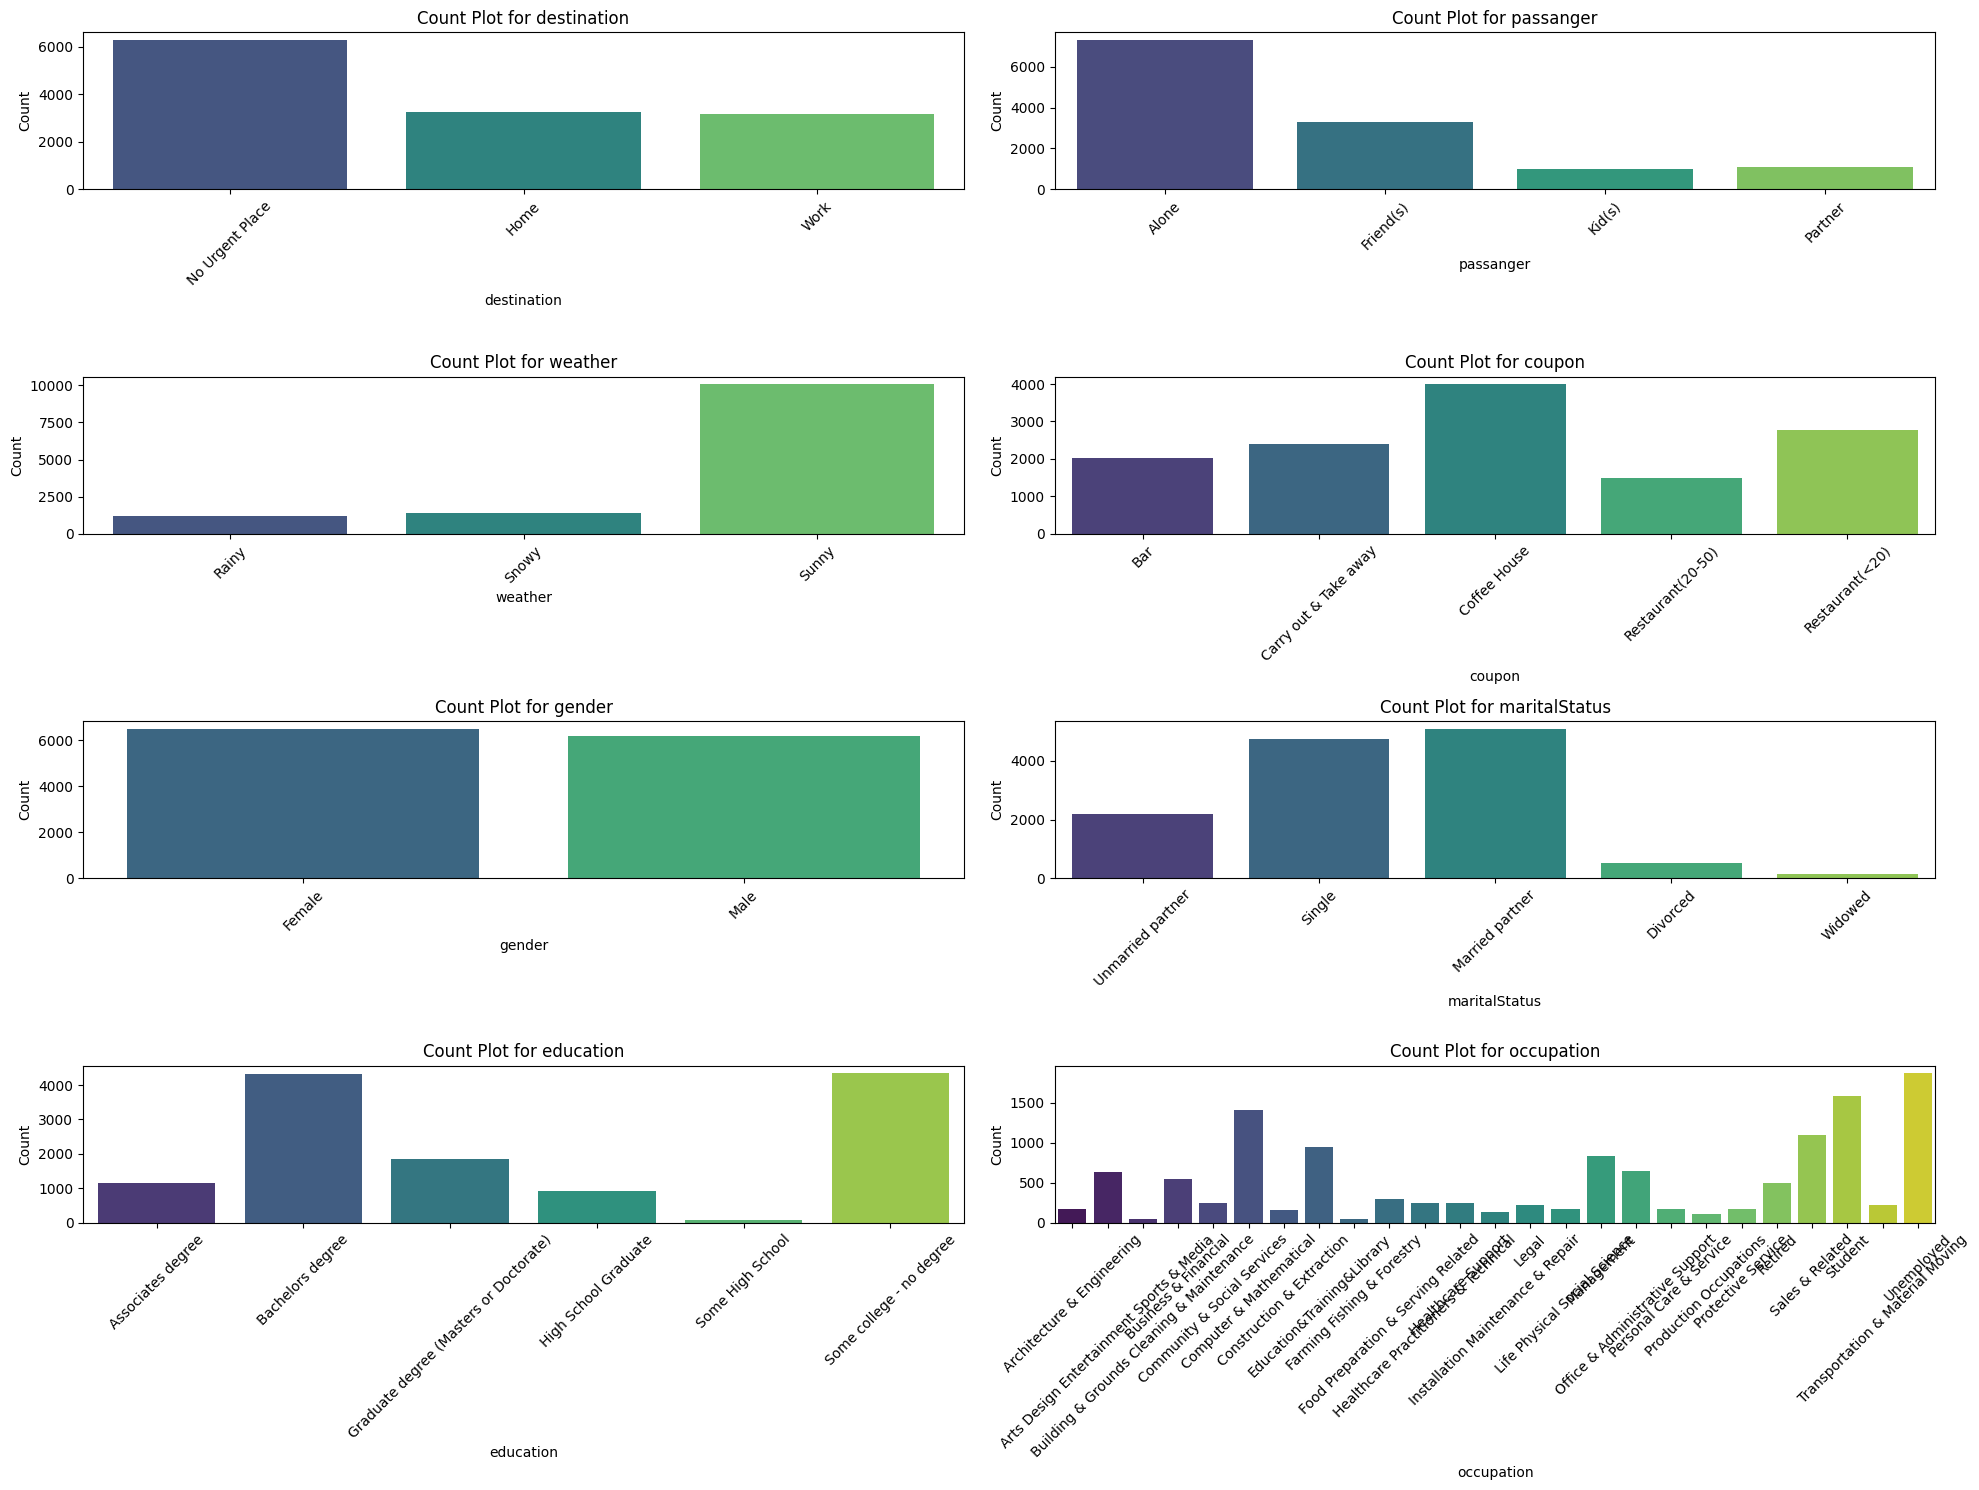

In [321]:
# List of categorical columns you want to plot
categorical_columns = ['destination', 'passanger', 'weather', 'coupon', 'gender', 'maritalStatus', 'education', 'occupation']

# Set up the matplotlib figure
plt.figure(figsize=(20, 15))

# Loop through the categorical columns and create a subplot for each
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(4, 2, i)  # Adjust the grid size according to the number of columns
    sns.countplot(data=datas, x=col, hue=col, palette='viridis', legend=False)  # Set hue to the column itself
    plt.title(f'Count Plot for {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

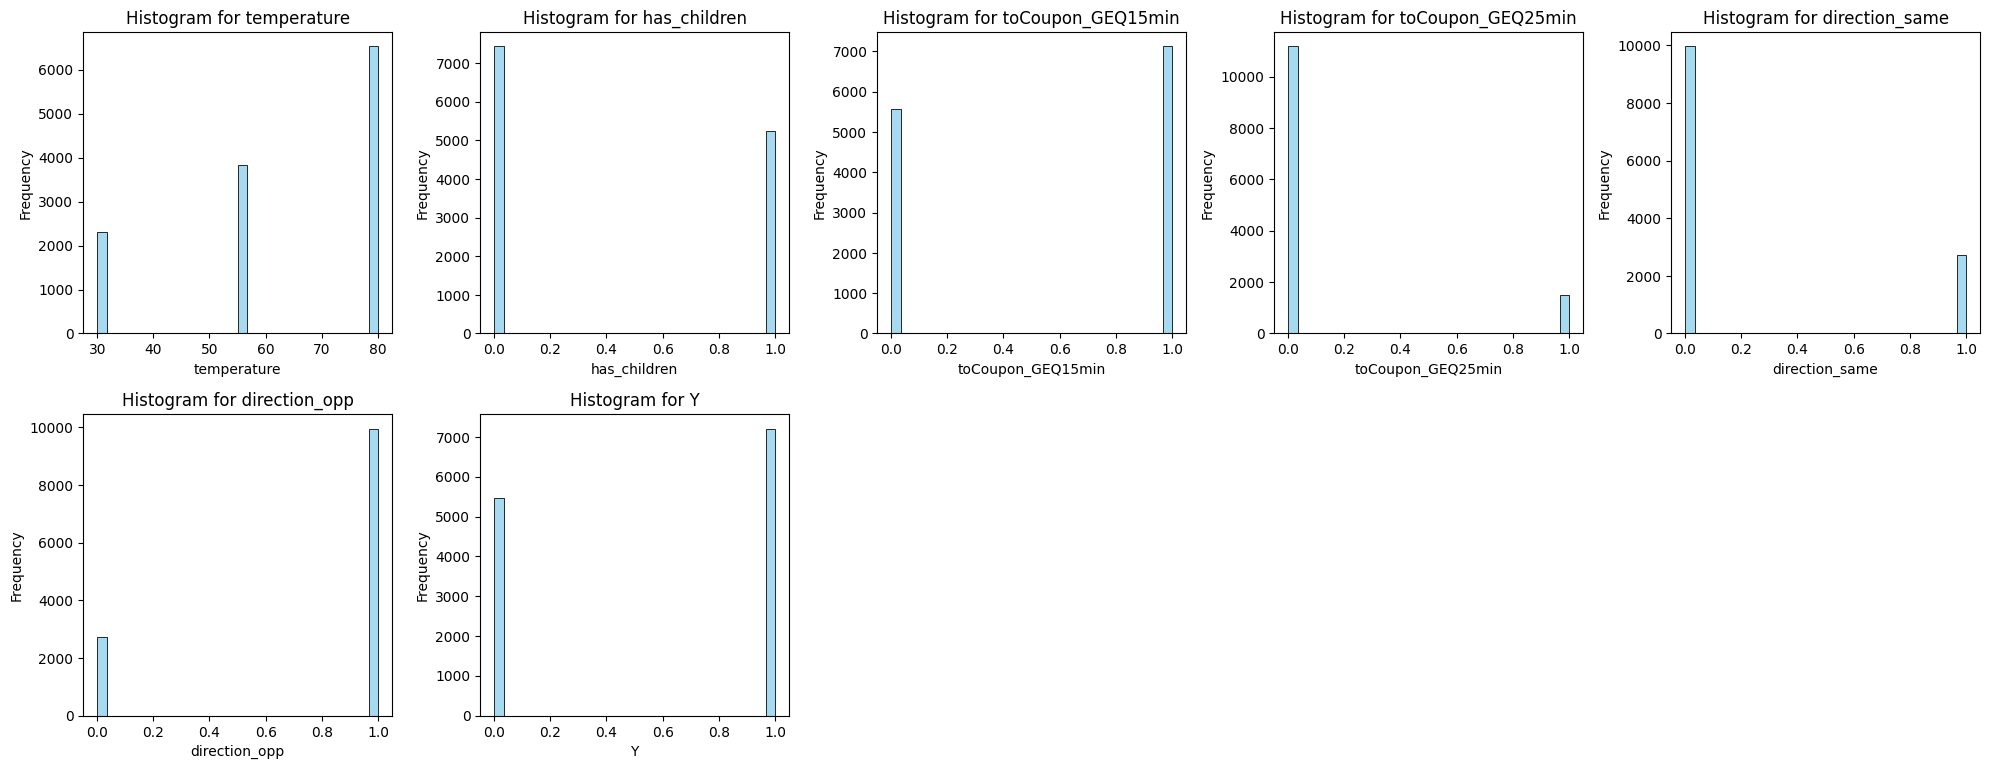

In [322]:
# Identify numerical columns
numerical_columns = datas.select_dtypes(include=['number']).columns

# Set up the matplotlib figure
plt.figure(figsize=(20, 15))

# Loop through the numerical columns and create a subplot for each
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(4, 5, i)  # Adjust the grid size according to the number of columns
    sns.histplot(datas[col], kde=False, bins=30, color='skyblue')  # Use sns.histplot for modern seaborn versions
    plt.title(f'Histogram for {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [323]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# Convert all object columns to category
df_obj = datas.select_dtypes(include=['object']).copy()

for col in df_obj.columns:
    datas[col] = datas[col].astype('category')

# Check the data types to confirm the changes
print(datas.dtypes)
encod = OneHotEncoder(dtype='int64')

datas_cat = datas.select_dtypes(include=['category']).copy()
datas_int = datas.select_dtypes(include=['int64']).copy()

datas_enc = pd.DataFrame()
for col in datas_cat.columns:
    enc_results = encod.fit_transform(datas_cat[[col]])
    dat = pd.DataFrame(enc_results.toarray(), columns=encod.categories_)
    datas_enc = pd.concat([datas_enc,dat], axis=1)

datas_final = pd.concat([datas_enc, datas_int], axis=1)

destination             category
passanger               category
weather                 category
temperature                int64
time                    category
coupon                  category
expiration              category
gender                  category
age                     category
maritalStatus           category
has_children               int64
education               category
occupation              category
income                  category
Bar                     category
CoffeeHouse             category
CarryAway               category
RestaurantLessThan20    category
Restaurant20To50        category
toCoupon_GEQ15min          int64
toCoupon_GEQ25min          int64
direction_same             int64
direction_opp              int64
Y                          int64
dtype: object


In [324]:
datas_final

,"(Home,)","(No Urgent Place,)","(Work,)","(Alone,)","(Friend(s),)","(Kid(s),)","(Partner,)","(Rainy,)","(Snowy,)","(Sunny,)",...,"(gt8,)","(less1,)","(never,)",temperature,has_children,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,0,1,0,1,0,0,0,0,0,1,...,0,0,0,55,1,0,0,0,1,1
1,0,1,0,0,1,0,0,0,0,1,...,0,0,0,80,1,0,0,0,1,0
2,0,1,0,0,1,0,0,0,0,1,...,0,0,0,80,1,1,0,0,1,1
3,0,1,0,0,1,0,0,0,0,1,...,0,0,0,80,1,1,0,0,1,0
4,0,1,0,0,1,0,0,0,0,1,...,0,0,0,80,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,1,0,0,0,0,0,1,1,0,0,...,0,0,0,55,0,0,0,1,0,1
12680,0,0,1,1,0,0,0,1,0,0,...,0,0,0,55,0,0,0,0,1,1
12681,0,0,1,1,0,0,0,0,1,0,...,0,0,0,30,0,0,0,1,0,0
12682,0,0,1,1,0,0,0,0,1,0,...,0,0,0,30,0,1,1,0,1,0


Modelling

In [325]:
#split data into training and test set
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(datas_final, test_size=.3, random_state=42, shuffle=True, stratify=datas_final['Y'])

In [326]:
#Creating the Dependent Feature Matrix
X_train = train_set.iloc[:, :-1].values
X_test = test_set.iloc[:, :-1].values

#Creating the Independent Vector
y_train = train_set.iloc[:, -1].values
y_test = test_set.iloc[:, -1].values

KNN

In [331]:
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
# Fit the K-Nearest Neighbors model
KNN = KNeighborsClassifier().fit(X_train, y_train)

# Predict the response for the test dataset
y_pred_KNN = KNN.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_KNN)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_KNN)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_KNN))

# Print accuracy
print(f"Accuracy: {accuracy:.4f}")

# Print confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.53      0.56      1643
           1       0.67      0.72      0.69      2163

    accuracy                           0.64      3806
   macro avg       0.63      0.63      0.63      3806
weighted avg       0.64      0.64      0.64      3806

Accuracy: 0.6393
Confusion Matrix:
[[ 877  766]
 [ 607 1556]]


SVM

In [333]:
# Fit the Support Vector Machine model
from sklearn.svm import SVC
SVM = SVC(kernel="rbf", random_state=None, probability=True, cache_size=500, gamma=0.1).fit(X_train, y_train)

# Predict the response for the test dataset
y_pred_SVM = SVM.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_SVM)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_SVM)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_SVM))

# Print accuracy
print(f"Accuracy: {accuracy:.4f}")

# Print confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.61      0.65      1643
           1       0.73      0.81      0.77      2163

    accuracy                           0.72      3806
   macro avg       0.72      0.71      0.71      3806
weighted avg       0.72      0.72      0.72      3806

Accuracy: 0.7236
Confusion Matrix:
[[ 997  646]
 [ 406 1757]]


Logistic Regression

In [335]:
# Fit the Logistic Regression model
LR = LogisticRegression(random_state=0, solver='lbfgs', multi_class='ovr',max_iter=1000).fit(X_train, y_train)

# Predict the response for the test dataset
y_pred_LR = LR.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_LR)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_LR)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_LR))

# Print accuracy
print(f"Accuracy: {accuracy:.4f}")

# Print confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.55      0.60      1643
           1       0.69      0.78      0.73      2163

    accuracy                           0.68      3806
   macro avg       0.67      0.66      0.66      3806
weighted avg       0.68      0.68      0.67      3806

Accuracy: 0.6792
Confusion Matrix:
[[ 897  746]
 [ 475 1688]]


Decision Tree

In [336]:
# Fit the Decision Tree Classifier model
DTC = DecisionTreeClassifier().fit(X_train, y_train)

# Predict the response for the test dataset
y_pred_DTC = DTC.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_DTC)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_DTC)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_DTC))

# Print accuracy
print(f"Accuracy: {accuracy:.4f}")

# Print confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.63      0.63      1643
           1       0.72      0.73      0.73      2163

    accuracy                           0.69      3806
   macro avg       0.68      0.68      0.68      3806
weighted avg       0.69      0.69      0.69      3806

Accuracy: 0.6863
Confusion Matrix:
[[1035  608]
 [ 586 1577]]


Support Vector Machine performs the best among the models in terms of accuracy, precision, recall, and F1-score.

Fine Tuning

In [338]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# Define the parameter distribution
param_dist_svm = {
    'C': np.logspace(-3, 3, 7),  # Regularization parameter
    'gamma': np.logspace(-3, 3, 7),  # Kernel coefficient
    'kernel': ['linear', 'rbf', 'poly']  # Kernel type
}

# Create the SVM model
svm = SVC(probability=True, cache_size=500, random_state=0)

# Set up RandomizedSearchCV
random_search_svm = RandomizedSearchCV(estimator=svm, param_distributions=param_dist_svm,
                                        n_iter=50, cv=5, scoring='accuracy',
                                        n_jobs=-1, random_state=0)

# Fit RandomizedSearchCV
random_search_svm.fit(X_train, y_train)

# Get the best parameters and score
print("Best parameters for SVM:", random_search_svm.best_params_)
print("Best accuracy score for SVM:", random_search_svm.best_score_)

# Use the best model from RandomizedSearchCV
best_svm_random = random_search_svm.best_estimator_

# Predict the response for the test dataset
y_pred_best_SVM_random = best_svm_random.predict(X_test)

# Calculate accuracy
accuracy_best_random = accuracy_score(y_test, y_pred_best_SVM_random)

# Calculate confusion matrix
conf_matrix_best_random = confusion_matrix(y_test, y_pred_best_SVM_random)

# Print the classification report
print("Classification Report (Best SVM from RandomizedSearchCV):")
print(classification_report(y_test, y_pred_best_SVM_random))

# Print accuracy
print(f"Accuracy (Best SVM from RandomizedSearchCV): {accuracy_best_random:.4f}")

# Print confusion matrix
print("Confusion Matrix (Best SVM from RandomizedSearchCV):")
print(conf_matrix_best_random)